In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('planilha_atualizada.xlsx')
print(df)

                Nome Departamento  Turno  Faltas Dia_da_Semana_Ultima_Falta  \
0    Colaborador_001    Operações  Manhã       2                     Quarta   
1    Colaborador_002    Operações  Manhã       1                    Segunda   
2    Colaborador_003       Vendas  Manhã       3                    Segunda   
3    Colaborador_004    Marketing  Manhã       3                    Segunda   
4    Colaborador_005           RH  Manhã       1                     Quarta   
..               ...          ...    ...     ...                        ...   
214  Colaborador_215    Operações  Tarde       3                    Segunda   
215  Colaborador_216    Operações  Manhã       1                    Segunda   
216  Colaborador_217   Financeiro  Tarde       2                    Segunda   
217  Colaborador_218           RH  Tarde       1                      Terça   
218  Colaborador_219   Financeiro  Manhã       0                      Sexta   

    Data_Ultima_Falta Evadiu  Faltas_Suspeitas  
0 

Exercicio 1

A)

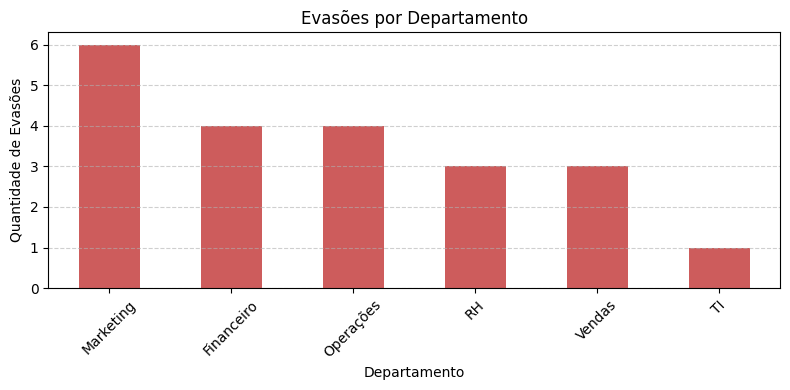

In [8]:
evasoes = df[df['Evadiu'] == 'Sim'].value_counts('Departamento')
evasoes.plot(kind='bar', color='indianred', figsize=(8, 4))
plt.title("Evasões por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Quantidade de Evasões")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Análise

 

B)

Percentual de evasão no turno da tarde: 8.85%


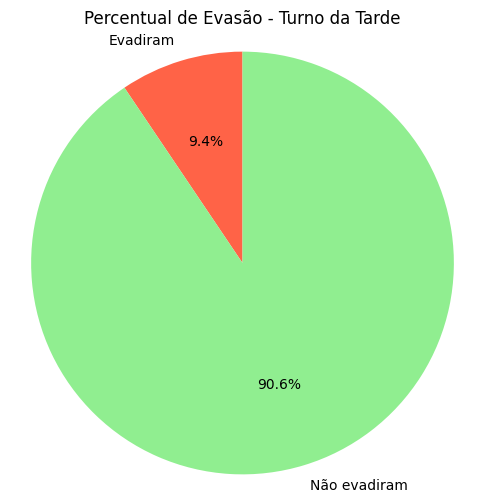

In [9]:
tarde_df = df[df["Turno"] == "Tarde"]
percentual_evasao_tarde = (tarde_df["Evadiu"] == "Sim").mean() * 100
print(f"Percentual de evasão no turno da tarde: {percentual_evasao_tarde:.2f}%")
df["Evasao_Tarde_Sim"] = ((df["Turno"] == "Tarde") & (df["Evadiu"] == "Sim")).astype(int)
df["Evasao_Tarde_Nao"] = ((df["Turno"] == "Tarde") & (df["Evadiu"] == "Não")).astype(int)
evasao_tarde_sim = df["Evasao_Tarde_Sim"].sum()
evasao_tarde_nao = df["Evasao_Tarde_Nao"].sum()
plt.figure(figsize=(6, 6))
plt.pie(
    [evasao_tarde_sim, evasao_tarde_nao],
    labels=["Evadiram", "Não evadiram"],
    autopct='%1.1f%%',
    colors=["tomato", "lightgreen"],
    startangle=90
)
plt.title('Percentual de Evasão - Turno da Tarde')
plt.axis('equal')
plt.show()


Análise


C)

Desvio padrão de faltas por turno:
Turno
Manhã    1.376872
Tarde    1.430269
Name: Faltas, dtype: float64


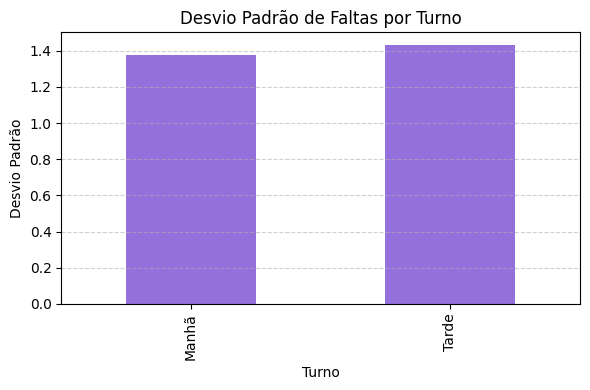

In [10]:
desvio_padrao = df.groupby("Turno")["Faltas"].std()
print("Desvio padrão de faltas por turno:")
print(desvio_padrao)
plt.figure(figsize=(6, 4))
desvio_padrao.plot(kind='bar', color='mediumpurple')
plt.title('Desvio Padrão de Faltas por Turno')
plt.ylabel('Desvio Padrão')
plt.xlabel('Turno')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Análise


Exercicio 2

A)

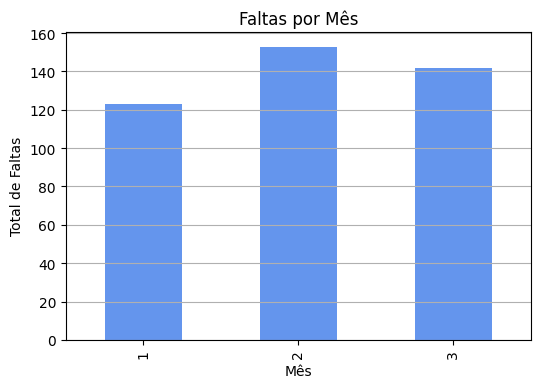

In [11]:
df["Data_Ultima_Falta"] = pd.to_datetime(df["Data_Ultima_Falta"], errors='coerce')
df["Mes_Falta"] = df["Data_Ultima_Falta"].dt.month
faltas_mes = df.groupby("Mes_Falta")["Faltas"].sum()
faltas_mes.plot(kind="bar", color='cornflowerblue', title="Faltas por Mês", figsize=(6,4))
plt.xlabel("Mês")
plt.ylabel("Total de Faltas")
plt.grid(axis='y')
plt.show()


Análise


B)

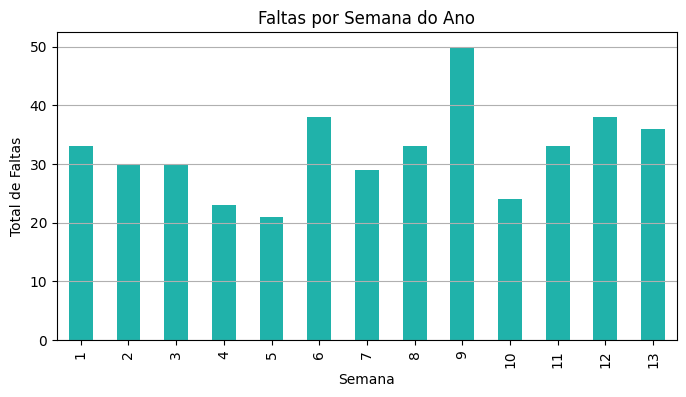

In [12]:
df["Semana_Ultima_Falta"] = df["Data_Ultima_Falta"].dt.isocalendar().week
faltas_semana = df.groupby("Semana_Ultima_Falta")["Faltas"].sum()
faltas_semana.plot(kind="bar", color='lightseagreen', title="Faltas por Semana do Ano", figsize=(8,4))
plt.xlabel("Semana")
plt.ylabel("Total de Faltas")
plt.grid(axis='y')
plt.show()


Análise


C)

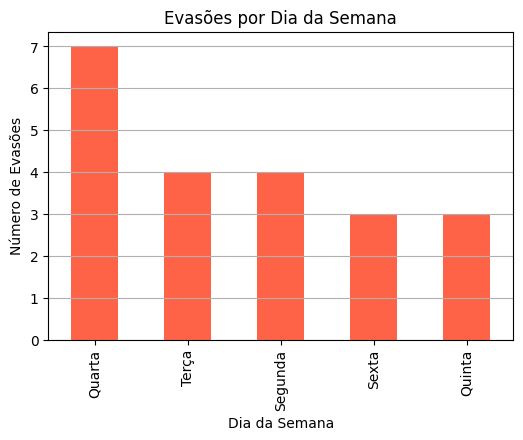

In [13]:
evasoes_dia = df[df["Evadiu"] == "Sim"]["Dia_da_Semana_Ultima_Falta"].value_counts()
evasoes_dia.plot(kind="bar", color='tomato', title="Evasões por Dia da Semana", figsize=(6,4))
plt.xlabel("Dia da Semana")
plt.ylabel("Número de Evasões")
plt.grid(axis='y')
plt.show()


Análise


Exercicio 3

A)


In [14]:
def classificar_risco(row):
    if row["Evadiu"] == "Sim" or row["Faltas"] >= 3:
        return "Alto"
    elif row["Faltas"] == 2:
        return "Moderado"
    else:
        return "Baixo"

df["Risco_Evasao"] = df.apply(classificar_risco, axis=1)
df["Risco_Evasao"].value_counts()


Risco_Evasao
Baixo       93
Alto        73
Moderado    53
Name: count, dtype: int64

Análise


B)

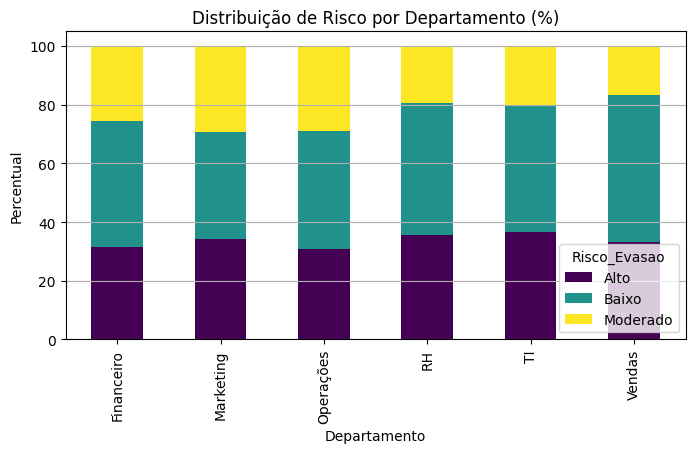

In [15]:
distribuicao_risco_departamento = pd.crosstab(df["Departamento"], df["Risco_Evasao"], normalize='index') * 100
distribuicao_risco_departamento.plot(kind="bar", stacked=True, figsize=(8,4), colormap="viridis")
plt.title("Distribuição de Risco por Departamento (%)")
plt.ylabel("Percentual")
plt.grid(axis='y')
plt.show()


Análise


C)

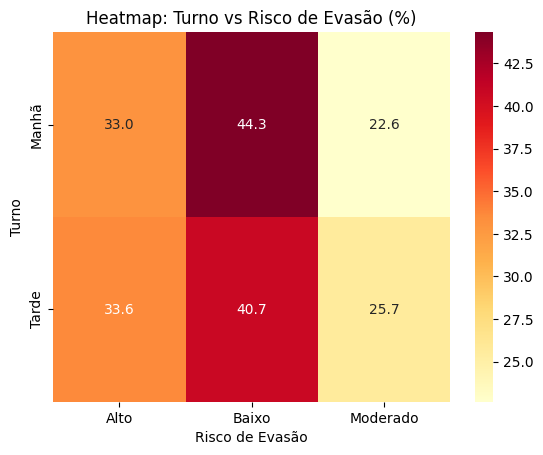

In [16]:
risco_turno = pd.crosstab(df["Turno"], df["Risco_Evasao"], normalize='index') * 100
sns.heatmap(risco_turno, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Heatmap: Turno vs Risco de Evasão (%)")
plt.ylabel("Turno")
plt.xlabel("Risco de Evasão")
plt.show()


Análise


Exercicio 4

A)

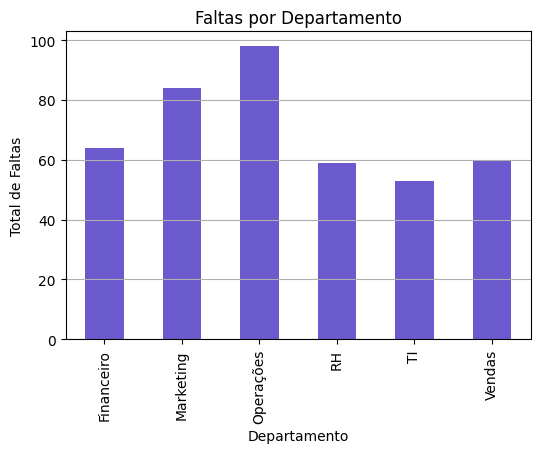

In [17]:
faltas_departamento = df.groupby("Departamento")["Faltas"].sum()
faltas_departamento.plot(kind="bar", color='slateblue', title="Faltas por Departamento", figsize=(6,4))
plt.ylabel("Total de Faltas")
plt.grid(axis='y')
plt.show()


Análise


B) 

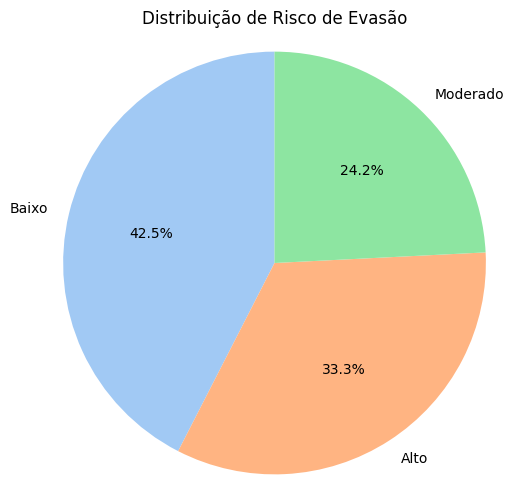

In [18]:
risco_distribuicao = df["Risco_Evasao"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(risco_distribuicao, labels=risco_distribuicao.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Distribuição de Risco de Evasão")
plt.axis('equal')
plt.show()


Análise


C)

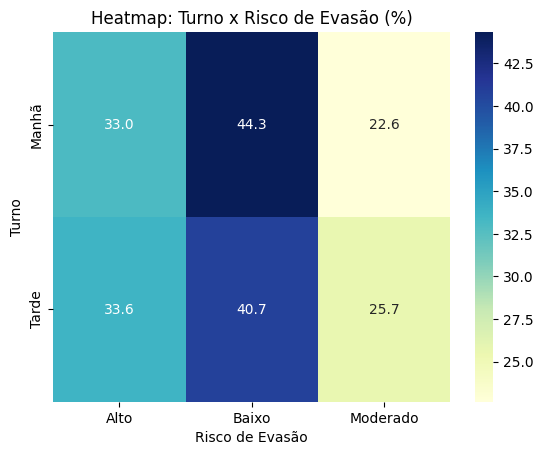

In [19]:
heatmap_data = pd.crosstab(df["Turno"], df["Risco_Evasao"], normalize='index') * 100
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Heatmap: Turno x Risco de Evasão (%)")
plt.ylabel("Turno")
plt.xlabel("Risco de Evasão")
plt.show()


Análise
